In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv',
 'ml_cross_validation_calibration_dataset.csv',
 'hyperparameter_tuning_dataset.csv',
 'evaluation_threshold_calibration_dataset.csv',
 'student_performance.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

DATASET
   study_hours  attendance  previous_score  assignments_completed  \
0          3.6        83.9            45.7                      6   
1          7.7        58.8            89.6                      3   
2          6.1        62.3            67.8                      7   
3          5.2        95.4            85.5                      6   
4          2.1        82.3            57.6                      7   

   sleep_hours  internet_access  extracurricular  final_score  pass  
0          8.1                1                1         65.9     1  
1          4.6                0                1         67.7     1  
2          8.2                0                1         72.1     1  
3          4.6                1                1         79.9     1  
4          6.0                1                1         63.5     1  

Dataset Shape: (200, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   C

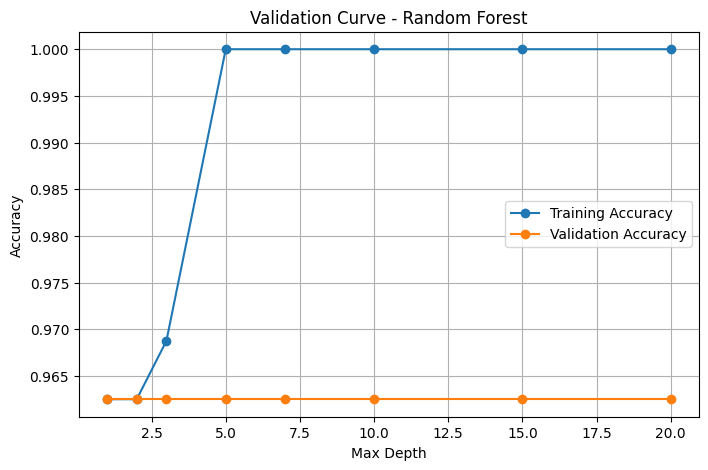


LEARNING CURVE
Training Set Sizes:
[ 16  32  48  64  80  96 112 128 144 160]

Training Accuracy:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Validation Accuracy:
[0.96  0.955 0.955 0.955 0.955 0.95  0.955 0.95  0.955 0.95 ]


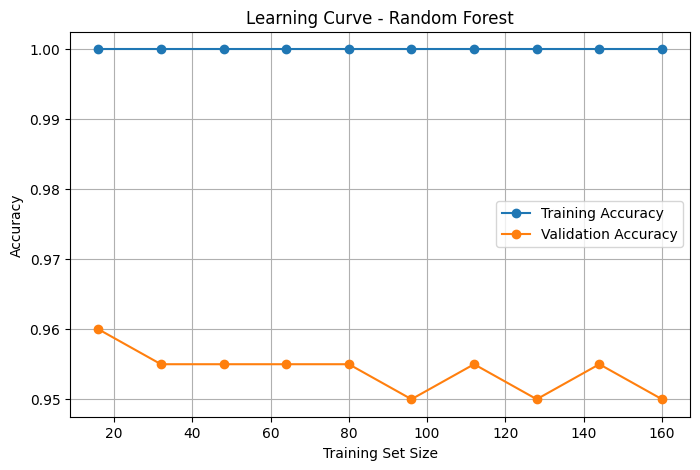


FINAL RESULTS
Basic Random Forest Accuracy      : 0.925
GridSearchCV Test Accuracy        : 0.95
RandomizedSearchCV Test Accuracy  : 0.95

GridSearchCV Best Parameters:
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}

RandomizedSearchCV Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 3}

PRACTICAL COMPLETED


In [8]:
# ============================================================
# MACHINE LEARNING PRACTICAL
# GridSearchCV, RandomizedSearchCV, Validation Curve
# and Learning Curve
# Dataset: Student Performance
# Algorithm: Random Forest Classifier
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    validation_curve,
    learning_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/Colab/student_performance.csv")

print("=" * 60)
print("DATASET")
print("=" * 60)

print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 3. DEFINE FEATURES AND TARGET
# ============================================================

# final_score is removed because it is directly related to pass
X = df.drop(columns=["final_score", "pass"])

# Target variable
y = df["pass"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("pass")


# ============================================================
# 4. SPLIT DATA INTO TRAINING AND TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# 5. BASIC RANDOM FOREST MODEL
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

basic_accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("BASIC RANDOM FOREST")
print("=" * 60)

print("Accuracy:", basic_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# 6. GRIDSEARCHCV
# ============================================================

print("\n" + "=" * 60)
print("GRIDSEARCHCV")
print("=" * 60)

# Parameters to test
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

# Results
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

# Test using best model
grid_pred = grid_search.predict(X_test)

grid_accuracy = accuracy_score(y_test, grid_pred)

print("\nGridSearch Test Accuracy:")
print(grid_accuracy)


# ============================================================
# 7. RANDOMIZEDSEARCHCV
# ============================================================

print("\n" + "=" * 60)
print("RANDOMIZEDSEARCHCV")
print("=" * 60)

# Parameter distributions
param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Create RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train, y_train)

# Results
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(random_search.best_score_)

# Test using best model
random_pred = random_search.predict(X_test)

random_accuracy = accuracy_score(y_test, random_pred)

print("\nRandomizedSearch Test Accuracy:")
print(random_accuracy)


# ============================================================
# 8. VALIDATION CURVE
# ============================================================

print("\n" + "=" * 60)
print("VALIDATION CURVE")
print("=" * 60)

# Values of max_depth to test
param_range = [1, 2, 3, 5, 7, 10, 15, 20]

# Calculate training and validation scores
train_scores, validation_scores = validation_curve(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Calculate mean scores
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

print("Max Depth Values:")
print(param_range)

print("\nTraining Accuracy:")
print(train_mean)

print("\nValidation Accuracy:")
print(validation_mean)


# Plot Validation Curve
plt.figure(figsize=(8, 5))

plt.plot(
    param_range,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    param_range,
    validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Validation Curve - Random Forest")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 9. LEARNING CURVE
# ============================================================

print("\n" + "=" * 60)
print("LEARNING CURVE")
print("=" * 60)

# Calculate learning curve
train_sizes, train_scores, validation_scores = learning_curve(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Calculate mean scores
learning_train_mean = train_scores.mean(axis=1)
learning_validation_mean = validation_scores.mean(axis=1)

print("Training Set Sizes:")
print(train_sizes)

print("\nTraining Accuracy:")
print(learning_train_mean)

print("\nValidation Accuracy:")
print(learning_validation_mean)


# Plot Learning Curve
plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    learning_train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    learning_validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 10. FINAL COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print("Basic Random Forest Accuracy      :", basic_accuracy)
print("GridSearchCV Test Accuracy        :", grid_accuracy)
print("RandomizedSearchCV Test Accuracy  :", random_accuracy)

print("\nGridSearchCV Best Parameters:")
print(grid_search.best_params_)

print("\nRandomizedSearchCV Best Parameters:")
print(random_search.best_params_)

print("\n" + "=" * 60)
print("PRACTICAL COMPLETED")
print("=" * 60)